# Alternative Data Test v6 — Fair Comparison

**Design principles:**
- ONE master dataframe, ONE set of windows, ONE train/test split
- All experiments use the SAME rows, SAME dates, SAME target — only columns differ
- Experiment A uses LOCKED params from original notebook (the 52.7% result)
- Experiments B and C get their own Optuna search

| Exp | Features | Optuna? |
|-----|----------|---------|
| A | FRED-MD + Price (32 cols) | No — locked to original params |
| B | FRED-MD + Alt + Price (80+ cols) | Yes — 10 trials |
| C | Alt + Price only (49 cols) | Yes — 10 trials |

In [ ]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.3 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random, warnings, os
from pathlib import Path
import seaborn as sns
import optuna
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
print('Imports loaded.')

Imports loaded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = Path('/content/drive/MyDrive/Quants ')
ALT_DIR = BASE_DIR / 'alternative_data' / 'raw'

Mounted at /content/drive


## 1. Load Data (identical to original notebook)

In [ ]:
# === WHEAT PRICES (exact code from working notebook) ===
W18 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
W25 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'
def load_price(p):
    df = pd.read_csv(p)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df['Price'] = df['Price'].astype(str).str.replace(',','',regex=False).astype(float)
    return df['Price']
p1, p2 = load_price(W18), load_price(W25)
df_price = pd.concat([p1, p2.iloc[1:]]).pipe(lambda s: s[~s.index.duplicated(keep='last')]).sort_index()
df_price.name = 'Price'
print(f'Wheat prices: {len(df_price)} days')

# === FRED-MD (exact code from working notebook) ===
fred_md_path = str(BASE_DIR / 'FredMD_Dataset' / '2025-10-MD.csv')
tcodes_row = pd.read_csv(fred_md_path, nrows=1)
fred_raw = pd.read_csv(fred_md_path, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()
features_31 = ['RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE',
    'BUSLOANS','CONSPI','S&P 500','S&P PE ratio','FEDFUNDS','TB3MS',
    'TB6MS','GS1','GS5','GS10','AAA','BAA','TB3SMFFM','TB6SMFFM',
    'T1YFFM','T5YFFM','T10YFFM','AAAFFM','BAAFFM',
    'EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx','PPICMM','UMCSENTx']
tcode_map = {c: int(float(tcodes_row[c].values[0])) for c in features_31}
def apply_tcode(s, tc):
    if tc==1: return s
    if tc==2: return s.diff()
    if tc==3: return s.diff().diff()
    if tc==4: return np.log(s.clip(lower=1e-10))
    if tc==5: return np.log(s.clip(lower=1e-10)).diff()
    if tc==6: return np.log(s.clip(lower=1e-10)).diff().diff()
    if tc==7: return (s/s.shift(1)-1).diff()
    return s
fs = fred_raw[features_31].copy().apply(pd.to_numeric, errors='coerce')
for c in features_31: fs[c] = apply_tcode(fs[c], tcode_map[c])
fred_t = fs.dropna().replace([np.inf,-np.inf],np.nan).dropna()
fred_t.index = fred_t.index + pd.DateOffset(months=1)
daily_idx = pd.date_range(fred_t.index.min(), fred_t.index.max()+pd.offsets.MonthEnd(0), freq='D')
df_macro = fred_t.reindex(daily_idx).ffill()
print(f'FRED-MD: {df_macro.shape}')

Wheat prices: 6864 days
FRED-MD: (17351, 31)


## 2. Load Alternative Data

In [ ]:
# === TECH INDICATORS ===
inv_dir = BASE_DIR / 'Investing.com'
all_wf = sorted([f for f in inv_dir.iterdir() if f.suffix=='.csv' and 'Wheat' in f.name])
wfull = pd.concat([pd.read_csv(f) for f in all_wf], ignore_index=True)
wfull['Date'] = pd.to_datetime(wfull['Date'], format='mixed', dayfirst=False)
wfull = wfull.sort_values('Date').drop_duplicates(subset='Date').set_index('Date')
for c in ['Price','Open','High','Low']:
    wfull[c] = pd.to_numeric(wfull[c].astype(str).str.replace(',',''), errors='coerce')
def pvol(v):
    v=str(v).strip().replace(',','')
    if v.endswith('K'): return float(v[:-1])*1000
    elif v.endswith('M'): return float(v[:-1])*1e6
    try: return float(v)
    except: return np.nan
wfull['Volume'] = wfull['Vol.'].apply(pvol)
c_,h_,l_,v_ = wfull['Price'],wfull['High'],wfull['Low'],wfull['Volume'].fillna(0)
tech = pd.DataFrame(index=wfull.index)
for n in [5,10,20]: tech[f'mom_{n}d'] = c_.pct_change(n)
d_=c_.diff(); g_=d_.clip(lower=0); lo_=(-d_).clip(lower=0)
tech['rsi']=100-(100/(1+g_.rolling(14).mean()/lo_.rolling(14).mean().replace(0,np.nan)))
e12_,e26_=c_.ewm(span=12).mean(),c_.ewm(span=26).mean()
macd_=e12_-e26_; tech['macd']=macd_; tech['macd_hist']=macd_-macd_.ewm(span=9).mean()
s20_,st20_=c_.rolling(20).mean(),c_.rolling(20).std()
tech['bb_pctb']=(c_-(s20_-2*st20_))/(4*st20_).replace(0,np.nan)
tr_=pd.concat([h_-l_,(h_-c_.shift(1)).abs(),(l_-c_.shift(1)).abs()],axis=1).max(axis=1)
tech['atr']=tr_.rolling(14).mean()
tech['vol_sma']=v_/v_.rolling(20).mean().replace(0,np.nan)
tech_cols = tech.columns.tolist()
print(f'Tech: {tech_cols}')

# === COT ===
cr_ = pd.read_csv(ALT_DIR/'cot_wheat_disaggregated.csv')
cr_['Date'] = pd.to_datetime(cr_['Report_Date_as_YYYY-MM-DD'])
nc_=['Open_Interest_All','Prod_Merc_Positions_Long_All','Prod_Merc_Positions_Short_All',
    'M_Money_Positions_Long_All','M_Money_Positions_Short_All']
for c2_ in nc_: cr_[c2_]=pd.to_numeric(cr_[c2_],errors='coerce')
cot_=cr_.groupby('Date')[nc_].sum().reset_index()
oi_=cot_['Open_Interest_All'].replace(0,np.nan)
cot_['mm_net']=cot_['M_Money_Positions_Long_All']-cot_['M_Money_Positions_Short_All']
cot_['cm_net']=cot_['Prod_Merc_Positions_Long_All']-cot_['Prod_Merc_Positions_Short_All']
cot_['hedge_pr']=cot_['cm_net']/oi_; cot_['spec_se']=cot_['mm_net']/oi_
cot_['pos_chg']=cot_['mm_net'].diff(4)
cot_['spec_z']=(cot_['mm_net']-cot_['mm_net'].rolling(52).mean())/cot_['mm_net'].rolling(52).std().replace(0,np.nan)
cot_['oi_lev']=cot_['Open_Interest_All']
cot_features=['hedge_pr','spec_se','pos_chg','spec_z','oi_lev']
cot_['Date']=cot_['Date']+pd.Timedelta(days=3)
cot_daily=cot_.set_index('Date')[cot_features].resample('D').ffill()
print(f'COT: {len(cot_daily)} rows')

# === CROSS-COMMODITY ===
ca_={'corn_futures.csv':'corn','soybean_futures.csv':'soy','crude_oil_wti.csv':'oil',
    'usd_index.csv':'usd','gold_futures.csv':'gold'}
cdfs_=[]
for fn_,lb_ in ca_.items():
    dd_=pd.read_csv(ALT_DIR/fn_,header=[0,1],index_col=0,parse_dates=True)
    dd_.columns=[c3_[0] for c3_ in dd_.columns]; dd_=dd_.reset_index()
    dd_['Date']=pd.to_datetime(dd_['Date']); dd_[f'{lb_}_cl']=pd.to_numeric(dd_['Close'],errors='coerce')
    cdfs_.append(dd_[['Date',f'{lb_}_cl']].dropna().set_index('Date'))
xc_=cdfs_[0]
for dd_ in cdfs_[1:]: xc_=xc_.join(dd_,how='outer')
xc_=xc_.sort_index().ffill().dropna()
xc_=xc_.join(df_price,how='inner')
xc_['wc_rat']=xc_['Price']/xc_['corn_cl'].replace(0,np.nan)
xc_['ws_rat']=xc_['Price']/xc_['soy_cl'].replace(0,np.nan)
xc_['wc_m20']=xc_['wc_rat'].pct_change(20); xc_['ws_m20']=xc_['ws_rat'].pct_change(20)
wr_=xc_['Price'].pct_change(10)
xc_['rel_cn']=wr_-xc_['corn_cl'].pct_change(10); xc_['rel_ol']=wr_-xc_['oil_cl'].pct_change(10)
xc_['usd_c10']=xc_['usd_cl'].pct_change(10); xc_['gld_c10']=xc_['gold_cl'].pct_change(10)
cross_fcols=['wc_rat','ws_rat','wc_m20','ws_m20','rel_cn','rel_ol','usd_c10','gld_c10']
cross_daily=xc_[cross_fcols]
print(f'Cross: {len(cross_daily)} rows')

# === GOOGLE TRENDS + WEATHER + VIX/OVX + NASA ===
gt_=pd.read_csv(ALT_DIR/'google_trends.csv',parse_dates=['Date'],index_col='Date')
gt_cols=[c4_ for c4_ in gt_.columns if c4_!='isPartial']; gt_=gt_[gt_cols].resample('D').ffill()
print(f'Trends: {len(gt_)} rows')
wk_=pd.read_csv(ALT_DIR/'weather_kansas.csv',parse_dates=['Date'],index_col='Date')
wnd_=pd.read_csv(ALT_DIR/'weather_north_dakota.csv',parse_dates=['Date'],index_col='Date')
weather_=wk_.join(wnd_,how='outer',lsuffix='',rsuffix='').sort_index().ffill().dropna()
weather_cols=weather_.columns.tolist()
print(f'Weather: {len(weather_)} rows, {len(weather_cols)} features')
vix_=pd.read_csv(ALT_DIR/'vix.csv',parse_dates=['Date'],index_col='Date')
ovx_=pd.read_csv(ALT_DIR/'ovx.csv',parse_dates=['Date'],index_col='Date')
fear_=vix_.join(ovx_,how='outer').sort_index().ffill().dropna()
fear_cols=fear_.columns.tolist()
print(f'VIX/OVX: {len(fear_)} rows')
nasa_=pd.read_csv(ALT_DIR/'nasa_power_ag.csv',parse_dates=['Date'],index_col='Date').dropna()
nasa_cols=nasa_.columns.tolist()
print(f'NASA: {len(nasa_)} rows')

Tech: ['mom_5d', 'mom_10d', 'mom_20d', 'rsi', 'macd', 'macd_hist', 'bb_pctb', 'atr', 'vol_sma']
COT: 4740 rows
Cross: 4514 rows
Trends: 5814 rows
Weather: 5844 rows, 12 features
VIX/OVX: 4528 rows
NASA: 5844 rows


## 3. Build ONE Master DataFrame

Start from the baseline (FRED-MD + Price), then JOIN alt data columns to the SAME index.
This guarantees all experiments have the same rows.

In [ ]:
# Start with baseline: FRED-MD + Price (same as original notebook)
df_master = df_macro.join(df_price, how='inner').loc['2008-01-01':]

# Join all alt data to the SAME index — ffill/bfill for dates before alt data starts
alt_frames = [tech, cot_daily, cross_daily, gt_, weather_, fear_, nasa_]
for af in alt_frames:
    df_master = df_master.join(af, how='left')

# Fill NaN from alt data (dates before it starts get bfilled)
df_master = df_master.ffill().bfill()
df_master = df_master.replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna()

# Identify column groups
fred_cols = features_31  # 31 FRED columns
alt_cols = tech_cols + cot_features + cross_fcols + gt_cols + weather_cols + fear_cols + nasa_cols

print(f'Master shape: {df_master.shape}')
print(f'Date range: {df_master.index.min().date()} to {df_master.index.max().date()}')
print(f'FRED cols: {len(fred_cols)}')
print(f'Alt cols: {len(alt_cols)}')
print(f'Price: 1')
print(f'Total: {len(fred_cols) + len(alt_cols) + 1}')

Master shape: (4635, 80)
Date range: 2008-01-01 to 2025-08-29
FRED cols: 31
Alt cols: 48
Price: 1
Total: 80


## 4. Create Windows ONCE, Split ONCE

In [ ]:
LB = 30

# Use ALL columns to create windows (we'll select subsets later)
all_cols = fred_cols + alt_cols + ['Price']  # Price always last
df_ordered = df_master[all_cols]

pidx = df_ordered.columns.get_loc('Price')
data = df_ordered.values

X_all, y_all = [], []
for i in range(LB, len(data)):
    X_all.append(data[i-LB:i])
    y_all.append(1 if data[i, pidx] > data[i-1, pidx] else 0)
X_all = np.array(X_all)
y_all = np.array(y_all)

sp = int(len(X_all) * 0.8)
X_train_all, y_train = X_all[:sp], y_all[:sp]
X_test_all, y_test = X_all[sp:], y_all[sp:]

print(f'Total windows: {len(X_all)}')
print(f'Train: {len(X_train_all)}, Test: {len(X_test_all)}')
print(f'y_train Up: {y_train.mean():.1%}, y_test Up: {y_test.mean():.1%}')
print(f'Full feature dim: {X_train_all.shape[2]}')

# Column indices for each experiment
all_col_names = list(df_ordered.columns)
fred_price_idx = [all_col_names.index(c) for c in fred_cols + ['Price']]
alt_price_idx = [all_col_names.index(c) for c in alt_cols + ['Price']]
everything_idx = list(range(len(all_col_names)))

print(f'\nExp A (FRED+Price): {len(fred_price_idx)} cols')
print(f'Exp B (ALL):        {len(everything_idx)} cols')
print(f'Exp C (Alt+Price):  {len(alt_price_idx)} cols')

Total windows: 4605
Train: 3684, Test: 921
y_train Up: 47.8%, y_test Up: 46.0%
Full feature dim: 80

Exp A (FRED+Price): 32 cols
Exp B (ALL):        80 cols
Exp C (Alt+Price):  49 cols


## 5. BiGRU Classifier (identical to working notebook)

In [ ]:
class BiGRUClassifier:
    def __init__(self, hidden_size=64, num_layers=2, weight_decay=0.02,
                 dropout=0.2, early_stop_patience=10, epochs=100,
                 batch_size=64, learning_rate=1e-3):
        self.hidden_size=hidden_size; self.num_layers=num_layers
        self.weight_decay=weight_decay; self.dropout=dropout
        self.early_stop_patience=early_stop_patience
        self.epochs=epochs; self.batch_size=batch_size
        self.learning_rate=learning_rate
        self.model=None; self.x_scaler=None

    def _build_model(self, seq_length, feature_dim):
        inputs = Input(shape=(seq_length, feature_dim))
        h = layers.Bidirectional(layers.GRU(
            units=self.hidden_size, dropout=self.dropout,
            kernel_regularizer=regularizers.l2(self.weight_decay),
            return_sequences=True))(inputs)
        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(layers.GRU(
                units=self.hidden_size, dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True))(h)
        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)
        outputs = layers.Dense(1, activation='sigmoid',
                               kernel_regularizer=regularizers.l2(self.weight_decay))(x)
        return Model(inputs=inputs, outputs=outputs)

    def _scale_X(self, X, fit=False):
        n, lb, nf = X.shape
        flat = X.reshape(n, lb*nf)
        if fit:
            self.x_scaler = StandardScaler()
            flat = self.x_scaler.fit_transform(flat)
        else:
            flat = self.x_scaler.transform(flat)
        return flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        Xs = self._scale_X(X_train, fit=True)
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
        self.model = self._build_model(X_train.shape[1], X_train.shape[2])
        self.model.compile(optimizer=Adam(learning_rate=self.learning_rate),
                           loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(Xs, y_train, epochs=self.epochs, batch_size=self.batch_size,
                       shuffle=False, class_weight={0:cw[0],1:cw[1]}, verbose=0,
                       callbacks=[
                           EarlyStopping(monitor='loss', patience=self.early_stop_patience,
                                         restore_best_weights=True),
                           ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)])
        p = (self.model.predict(Xs, verbose=0).ravel()>=0.5).astype(int)
        print(f'  Train Acc: {accuracy_score(y_train,p):.4f} F1: {f1_score(y_train,p,zero_division=0):.4f}')

    def predict(self, X):
        return self.model.predict(self._scale_X(X), verbose=0).ravel()

    def evaluate(self, X, y):
        pr = self.predict(X); pd_ = (pr>=0.5).astype(int)
        m = {'accuracy': accuracy_score(y,pd_), 'precision': precision_score(y,pd_,zero_division=0),
             'recall': recall_score(y,pd_,zero_division=0), 'f1': f1_score(y,pd_,zero_division=0)}
        try: m['auc_roc'] = roc_auc_score(y,pr)
        except: m['auc_roc'] = 0.5
        return m

def cv_bigru(X_train, y_train, **kw):
    tscv = TimeSeriesSplit(n_splits=5)
    lb, nf = X_train.shape[1], X_train.shape[2]
    fm = {k:[] for k in ['accuracy','precision','recall','f1','auc_roc','val_loss']}
    for fold,(ti,vi) in enumerate(tscv.split(X_train)):
        Xtr, Xv = X_train[ti], X_train[vi]
        ytr, yv = y_train[ti], y_train[vi]
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr.reshape(len(Xtr),-1)).reshape(len(Xtr),lb,nf)
        Xv_s = sc.transform(Xv.reshape(len(Xv),-1)).reshape(len(Xv),lb,nf)
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)
        tmp = BiGRUClassifier(**kw)
        model = tmp._build_model(lb, nf)
        model.compile(optimizer=Adam(learning_rate=kw.get('learning_rate',1e-3)),
                       loss='binary_crossentropy', metrics=['accuracy'])
        h = model.fit(Xtr_s, ytr, validation_data=(Xv_s, yv),
                      epochs=kw.get('epochs',100), batch_size=kw.get('batch_size',64),
                      shuffle=False, class_weight={0:cw[0],1:cw[1]}, verbose=0,
                      callbacks=[
                          EarlyStopping(monitor='val_loss', patience=kw.get('early_stop_patience',10),
                                        restore_best_weights=True),
                          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)])
        fm['val_loss'].append(min(h.history['val_loss']))
        vp = model.predict(Xv_s, verbose=0).ravel()
        vpd = (vp>=0.5).astype(int)
        fm['accuracy'].append(accuracy_score(yv,vpd))
        fm['precision'].append(precision_score(yv,vpd,zero_division=0))
        fm['recall'].append(recall_score(yv,vpd,zero_division=0))
        fm['f1'].append(f1_score(yv,vpd,zero_division=0))
        try: fm['auc_roc'].append(roc_auc_score(yv,vp))
        except: fm['auc_roc'].append(0.5)
        print(f'    Fold {fold+1}: Acc={fm["accuracy"][-1]:.4f} F1={fm["f1"][-1]:.4f} AUC={fm["auc_roc"][-1]:.4f}')
    return {k:np.mean(v) for k,v in fm.items()}

print('BiGRUClassifier + CV defined.')

BiGRUClassifier + CV defined.


## 6. Experiment A: FRED-MD Only (LOCKED params from original 52.7% result)

In [ ]:
print('='*60)
print('  Exp A: FRED-MD only — LOCKED params (no Optuna)')
print('  These are the exact params that produced 52.7% in the original notebook')
print('='*60)

# Select FRED + Price columns from the shared arrays
Xtr_A = X_train_all[:, :, fred_price_idx]
Xte_A = X_test_all[:, :, fred_price_idx]
print(f'  Shape: Train={Xtr_A.shape}, Test={Xte_A.shape}')

# LOCKED params from original notebook Optuna
LOCKED_PARAMS = dict(
    learning_rate=0.00028166002113075777,
    hidden_size=128,
    num_layers=3,
    weight_decay=1.805854225153223e-05,
    dropout=0.3710363084063122,
    early_stop_patience=10,
    epochs=50,
    batch_size=64,
)

random.seed(42); np.random.seed(42); tf.random.set_seed(42)
model_A = BiGRUClassifier(**LOCKED_PARAMS)
model_A.fit(Xtr_A, y_train)

probs_A = model_A.predict(Xte_A)
preds_A = (probs_A >= 0.5).astype(int)
m_A = model_A.evaluate(Xte_A, y_test)

print(f'\n  === Test Results ===')
print(f'  Accuracy:  {m_A["accuracy"]:.4f}')
print(f'  AUC-ROC:   {m_A["auc_roc"]:.4f}')
print(f'  F1:        {m_A["f1"]:.4f}')
print(f'  Pred >0.5: {(probs_A>0.5).sum()}/{len(probs_A)}  <0.5: {(probs_A<0.5).sum()}/{len(probs_A)}')
print(f'\n{classification_report(y_test, preds_A, target_names=["Down","Up"])}')

  Exp A: FRED-MD only — LOCKED params (no Optuna)
  These are the exact params that produced 52.7% in the original notebook
  Shape: Train=(3684, 30, 32), Test=(921, 30, 32)
  Train Acc: 0.5212 F1: 0.4658

  === Test Results ===
  Accuracy:  0.5266
  AUC-ROC:   0.5376
  F1:        0.5560
  Pred >0.5: 558/921  <0.5: 363/921

              precision    recall  f1-score   support

        Down       0.58      0.43      0.49       497
          Up       0.49      0.64      0.56       424

    accuracy                           0.53       921
   macro avg       0.54      0.54      0.52       921
weighted avg       0.54      0.53      0.52       921



## 7. Experiments B & C: Optuna Tuning

**Constrained search space** based on what we know works:
- weight_decay: [1e-5, 5e-4] (original found 1.8e-5; >1e-3 kills the model)
- dropout: [0.2, 0.4] (original found 0.37; >0.5 too aggressive)
- hidden_size: [64, 128] (both work)
- num_layers: [1, 3]

In [ ]:
N_TRIALS = 10  # more trials for better coverage

def run_optuna(name, X_train_exp, n_trials=N_TRIALS):
    print(f'\n{"="*60}')
    print(f'  OPTUNA: {name} ({X_train_exp.shape[2]} features, {n_trials} trials)')
    print(f'{"="*60}')

    def objective(trial):
        p = {
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
            'hidden_size': trial.suggest_categorical('hidden_size', [64, 128]),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 5e-4, log=True),
            'dropout': trial.suggest_float('dropout', 0.2, 0.4),
            'early_stop_patience': 10,
            'epochs': trial.suggest_categorical('epochs', [50, 100]),
            'batch_size': 64,
        }
        print(f'  Trial {trial.number}: wd={p["weight_decay"]:.6f} h={p["hidden_size"]} L={p["num_layers"]} lr={p["learning_rate"]:.6f} do={p["dropout"]:.3f}')
        avg = cv_bigru(X_train_exp, y_train, **p)
        print(f'  -> CV F1={avg["f1"]:.4f} AUC={avg["auc_roc"]:.4f}')
        return avg['f1']

    study = optuna.create_study(direction='maximize', study_name=name)
    study.optimize(objective, n_trials=n_trials)

    print(f'\n  Best F1: {study.best_value:.4f}')
    print(f'  Best params:')
    for k,v in study.best_params.items(): print(f'    {k}: {v}')
    # Add fixed params back
    bp = study.best_params.copy()
    bp['early_stop_patience'] = 10
    bp['batch_size'] = 64
    return bp

# Select columns for B and C
Xtr_B = X_train_all[:, :, everything_idx]
Xtr_C = X_train_all[:, :, alt_price_idx]

best_B = run_optuna('B. FRED-MD + Alt', Xtr_B, N_TRIALS)
best_C = run_optuna('C. Alt only', Xtr_C, N_TRIALS)


  OPTUNA: B. FRED-MD + Alt (80 features, 10 trials)
  Trial 0: wd=0.000028 h=128 L=1 lr=0.000786 do=0.255
    Fold 1: Acc=0.5130 F1=0.6081 AUC=0.5262
    Fold 2: Acc=0.4723 F1=0.5970 AUC=0.5127
    Fold 3: Acc=0.5098 F1=0.4975 AUC=0.5247
    Fold 4: Acc=0.5244 F1=0.3364 AUC=0.5185
    Fold 5: Acc=0.5195 F1=0.3218 AUC=0.5004
  -> CV F1=0.4722 AUC=0.5165
  Trial 1: wd=0.000015 h=64 L=2 lr=0.000200 do=0.356
    Fold 1: Acc=0.5000 F1=0.6196 AUC=0.5001
    Fold 2: Acc=0.5244 F1=0.3840 AUC=0.5176
    Fold 3: Acc=0.5130 F1=0.5364 AUC=0.5214
    Fold 4: Acc=0.5244 F1=0.4385 AUC=0.5330
    Fold 5: Acc=0.5228 F1=0.4682 AUC=0.5185
  -> CV F1=0.4893 AUC=0.5181
  Trial 2: wd=0.000277 h=128 L=1 lr=0.000140 do=0.315
    Fold 1: Acc=0.4821 F1=0.1017 AUC=0.5063
    Fold 2: Acc=0.5391 F1=0.4750 AUC=0.5405
    Fold 3: Acc=0.4886 F1=0.6432 AUC=0.5219
    Fold 4: Acc=0.5179 F1=0.3808 AUC=0.5266
    Fold 5: Acc=0.5016 F1=0.4047 AUC=0.4967
  -> CV F1=0.4011 AUC=0.5184
  Trial 3: wd=0.000120 h=64 L=1 lr=0.00

## 8. Final Test for B and C

In [ ]:
results = []
all_preds = {}

# A is already done
m_A['Experiment'] = 'A. FRED-MD only (baseline)'
m_A['Features'] = len(fred_price_idx)
results.append(m_A)
all_preds['A. FRED-MD only (baseline)'] = {'y_test': y_test, 'y_pred': preds_A, 'y_prob': probs_A}

# B and C
for name, col_idx, best_params in [
    ('B. FRED-MD + Alt Data', everything_idx, best_B),
    ('C. Alt Data only (no FRED)', alt_price_idx, best_C),
]:
    print(f'\n{"="*60}')
    print(f'  FINAL TEST: {name}')
    print(f'  Features: {len(col_idx)}')
    print(f'  Params: wd={best_params["weight_decay"]:.6f} h={best_params["hidden_size"]} L={best_params["num_layers"]}')
    print(f'{"="*60}')

    Xtr = X_train_all[:, :, col_idx]
    Xte = X_test_all[:, :, col_idx]

    random.seed(42); np.random.seed(42); tf.random.set_seed(42)
    model = BiGRUClassifier(**best_params)
    model.fit(Xtr, y_train)

    probs = model.predict(Xte)
    preds = (probs >= 0.5).astype(int)
    m = model.evaluate(Xte, y_test)
    m['Experiment'] = name
    m['Features'] = len(col_idx)
    results.append(m)
    all_preds[name] = {'y_test': y_test, 'y_pred': preds, 'y_prob': probs}

    print(f'\n  === Test Results ===')
    print(f'  Accuracy:  {m["accuracy"]:.4f}')
    print(f'  AUC-ROC:   {m["auc_roc"]:.4f}')
    print(f'  F1:        {m["f1"]:.4f}')
    print(f'  Pred >0.5: {(probs>0.5).sum()}/{len(probs)}  <0.5: {(probs<0.5).sum()}/{len(probs)}')
    print(f'\n{classification_report(y_test, preds, target_names=["Down","Up"])}')


  FINAL TEST: B. FRED-MD + Alt Data
  Features: 80
  Params: wd=0.000018 h=128 L=3
  Train Acc: 0.5478 F1: 0.5433

  === Test Results ===
  Accuracy:  0.4593
  AUC-ROC:   0.5084
  F1:        0.6204
  Pred >0.5: 888/921  <0.5: 33/921

              precision    recall  f1-score   support

        Down       0.48      0.03      0.06       497
          Up       0.46      0.96      0.62       424

    accuracy                           0.46       921
   macro avg       0.47      0.50      0.34       921
weighted avg       0.47      0.46      0.32       921


  FINAL TEST: C. Alt Data only (no FRED)
  Features: 49
  Params: wd=0.000377 h=64 L=2
  Train Acc: 0.5920 F1: 0.5637

  === Test Results ===
  Accuracy:  0.5244
  AUC-ROC:   0.5500
  F1:        0.5672
  Pred >0.5: 588/921  <0.5: 333/921

              precision    recall  f1-score   support

        Down       0.59      0.39      0.47       497
          Up       0.49      0.68      0.57       424

    accuracy                      

## 9. Results Comparison

In [ ]:
rdf = pd.DataFrame(results).set_index('Experiment')
print('='*70)
print('FINAL RESULTS — Fair Comparison (same rows, same split, same target)')
print('='*70)
print(rdf[['Features','accuracy','precision','recall','f1','auc_roc']].to_string(float_format='{:.4f}'.format))
print()
for name in rdf.index:
    print(f'{name}: Acc={rdf.loc[name,"accuracy"]:.4f} AUC={rdf.loc[name,"auc_roc"]:.4f} F1={rdf.loc[name,"f1"]:.4f}')

FINAL RESULTS — Fair Comparison (same rows, same split, same target)
                            Features  accuracy  precision  recall     f1  auc_roc
Experiment                                                                       
A. FRED-MD only (baseline)        32    0.5266     0.4892  0.6439 0.5560   0.5376
B. FRED-MD + Alt Data             80    0.4593     0.4583  0.9599 0.6204   0.5084
C. Alt Data only (no FRED)        49    0.5244     0.4881  0.6769 0.5672   0.5500

A. FRED-MD only (baseline): Acc=0.5266 AUC=0.5376 F1=0.5560
B. FRED-MD + Alt Data: Acc=0.4593 AUC=0.5084 F1=0.6204
C. Alt Data only (no FRED): Acc=0.5244 AUC=0.5500 F1=0.5672


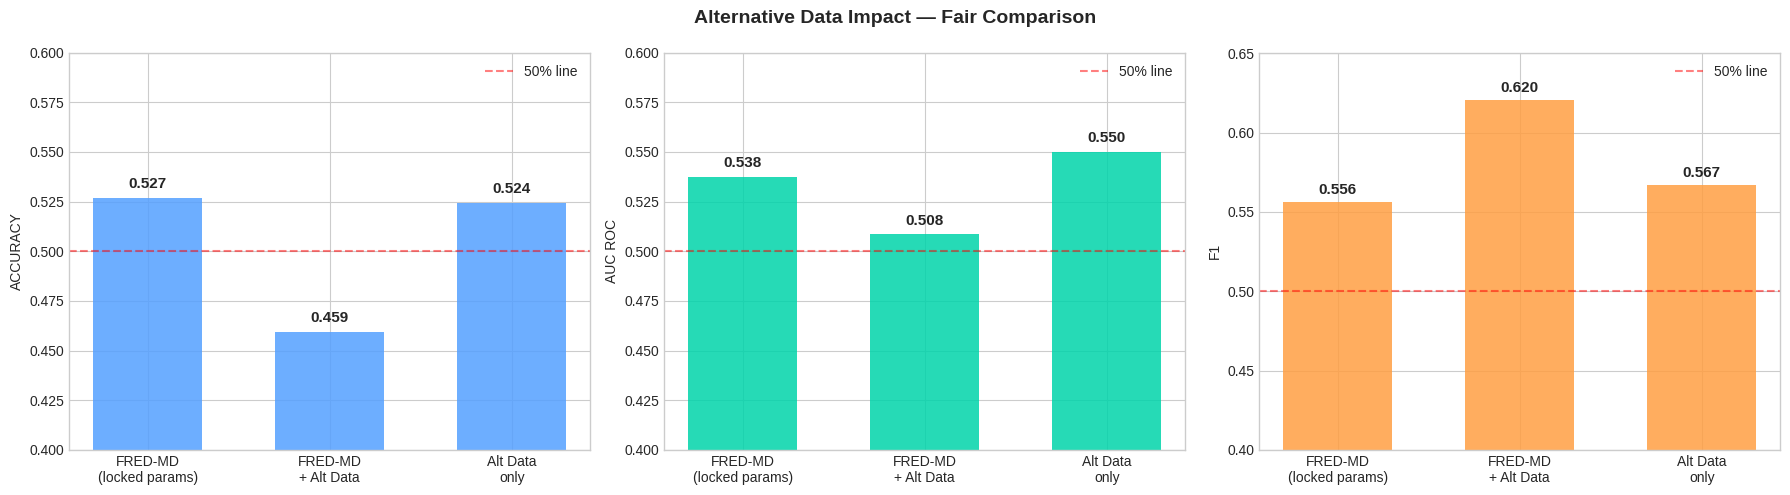

In [ ]:
# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['accuracy','auc_roc','f1'], ['#54A0FF','#00D4AA','#FF9F43']):
    vals = rdf[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=color, alpha=0.85, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['FRED-MD\n(locked params)', 'FRED-MD\n+ Alt Data', 'Alt Data\nonly'], fontsize=10)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% line')
    ax.set_ylabel(metric.replace('_',' ').upper()); ax.legend()
    ax.set_ylim(0.40, max(0.60, vals.max()+0.03))
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
fig.suptitle('Alternative Data Impact — Fair Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

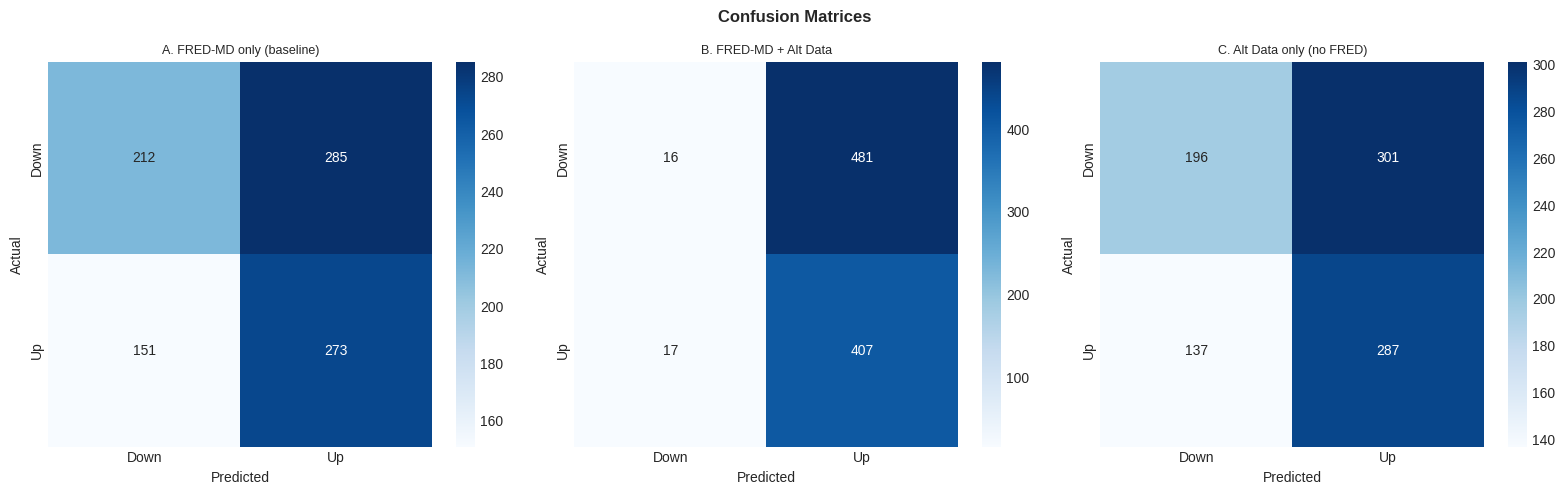

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, rdf.index):
    p = all_preds[name]
    cm = confusion_matrix(p['y_test'], p['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name, fontsize=9); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Save
out = str(BASE_DIR / 'alternative_data' / 'processed' / 'v6_final_results.csv')
os.makedirs(os.path.dirname(out), exist_ok=True)
rdf.to_csv(out)
print(f'Saved: {out}')
print()
print('Experiment A params (LOCKED):')
for k,v in LOCKED_PARAMS.items(): print(f'  {k}: {v}')
print(f'\nExperiment B params (Optuna):')
for k,v in best_B.items(): print(f'  {k}: {v}')
print(f'\nExperiment C params (Optuna):')
for k,v in best_C.items(): print(f'  {k}: {v}')

Saved: /content/drive/MyDrive/Quants /alternative_data/processed/v6_final_results.csv

Experiment A params (LOCKED):
  learning_rate: 0.00028166002113075777
  hidden_size: 128
  num_layers: 3
  weight_decay: 1.805854225153223e-05
  dropout: 0.3710363084063122
  early_stop_patience: 10
  epochs: 50
  batch_size: 64

Experiment B params (Optuna):
  learning_rate: 0.00011201762992736115
  hidden_size: 128
  num_layers: 3
  weight_decay: 1.789095683638314e-05
  dropout: 0.35338953236990356
  epochs: 100
  early_stop_patience: 10
  batch_size: 64

Experiment C params (Optuna):
  learning_rate: 0.0005243153969891159
  hidden_size: 64
  num_layers: 2
  weight_decay: 0.0003768266230504354
  dropout: 0.271729447955657
  epochs: 100
  early_stop_patience: 10
  batch_size: 64
